<a href="https://colab.research.google.com/github/paolopi81/geocentric-orbit-simulator/blob/main/Geocentric_orbit_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Insert initial distance in ER, approx. between 1.06 (ISS) and 235 (Hill's radius): 10
Insert a coefficient of multiplication for velocity. k=1: circular: 1<k<sqrt(2): ellipse; k>sqrt(2): escape: 2


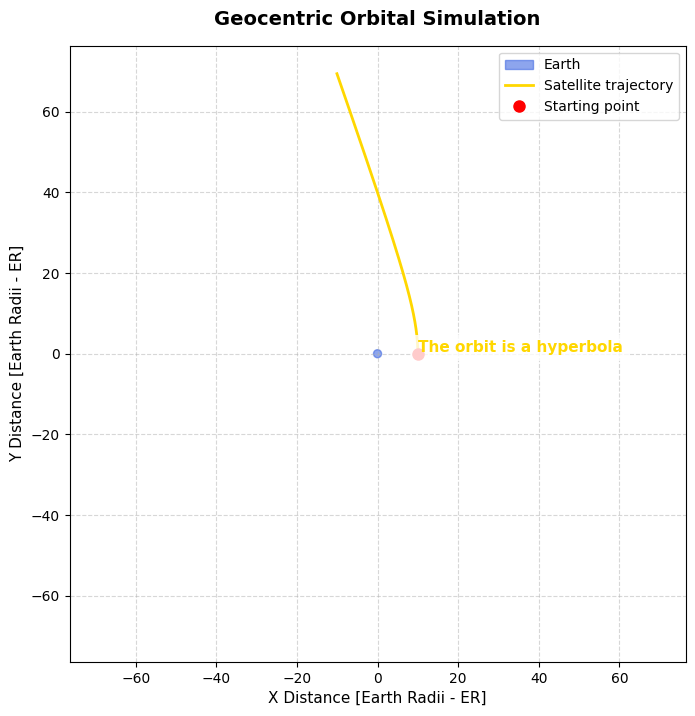

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import GM_earth, R_earth
from math import sqrt, pi
import sys

# INITIAL CONDITIONS
x0_ER = float(input("Insert initial distance in ER, approx. between 1.06 (ISS) and 235 (Hill's radius): "))
y0 = 0
k_v = float(input("Insert a coefficient of multiplication for velocity. k=1: circular: 1<k<sqrt(2): ellipse; k>sqrt(2): escape: "))

GM_earth = GM_earth.value
R_earth = R_earth.value

# CHECKING INPUTS
if x0_ER < 1 or x0_ER > 235:
    print("Invalid initial distance!")
    sys.exit()

if k_v < 1:
    print("The coefficient cannot be less than 1!")
    sys.exit()

# DEFINING PARAMETERS
x0 = R_earth * x0_ER
v_circ = sqrt(GM_earth / x0)
v0 = k_v * v_circ

# T_reference: reference circular period [s] used to simplify calculations on open orbits, that don't have a period
T_reference = 2 * pi * sqrt(x0**3 / GM_earth)

# Mechanical energy calculation: the satellite mass is simplified since it appears in all terms.
#If energy is negative the orbit will be closed (circumference or eclipse), else it will be a parabola (E=0) or a hyperbola (E>0)
mech_energy = 0.5 * v0**2 - GM_earth / x0
if mech_energy < 0:
    semi_axis = -GM_earth / (2 * mech_energy)
    # T: actual orbital period [s] calculated from the elliptic semi-major axis
    T = 2 * pi * sqrt(semi_axis**3 / GM_earth)
else:
    T = T_reference * 0.7 #this is to see better the curvature of open orbits

step = 20000
dt = T / step
check = 0

x = [x0]
y = [y0]
vx = [0]
vy = [v0]

distance = sqrt(x[-1]**2 + y[-1]**2)

# LOOP
while distance >= R_earth and check < step:
    ax = (-GM_earth * x[-1]) / distance**3
    ay = (-GM_earth * y[-1]) / distance**3

    next_vx = vx[-1] + ax * dt
    next_vy = vy[-1] + ay * dt

    next_x = x[-1] + next_vx * dt
    next_y = y[-1] + next_vy * dt

    x.append(next_x)
    y.append(next_y)
    vx.append(next_vx)
    vy.append(next_vy)

    distance = sqrt(x[-1]**2 + y[-1]**2)
    check += 1

# PLOTTING
x_ER = [_ / R_earth for _ in x]
y_ER = [_ / R_earth for _ in y]

if k_v == 1.0:
    orbit_type = "The orbit is a circumference"
    orbit_color = "limegreen"
elif 1.0 < k_v < 1.41:
    orbit_type = "The orbit is an ellipse"
    orbit_color = "powderblue"
elif  1.41 <= k_v < 1.42:
    orbit_type = "The orbit is a parabola"
    orbit_color = "maroon"
else:
    orbit_type = "The orbit is a hyperbola"
    orbit_color = "gold"

fig, ax = plt.subplots(figsize=(8, 8))

earth = plt.Circle((0, 0), 1.0, color='royalblue', alpha=0.6, label='Earth')
ax.add_patch(earth)

ax.plot(x_ER, y_ER, color=orbit_color, linewidth=2, label='Satellite trajectory')
ax.plot(x_ER[0], y_ER[0], 'ro', markersize=8, label='Starting point')

ax.text(x_ER[0], y_ER[0] + 0.4, orbit_type, color=orbit_color,
        fontsize=11, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

ax.set_xlabel('X Distance [Earth Radii - ER]', fontsize=11)
ax.set_ylabel('Y Distance [Earth Radii - ER]', fontsize=11)
ax.set_title('Geocentric Orbital Simulation', fontsize=14, fontweight='bold', pad=15)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='upper right')

max_coordinate = max(max(abs(np.array(x_ER))), max(abs(np.array(y_ER))))
limits = max_coordinate * 1.1

ax.set_xlim(-limits, limits)
ax.set_ylim(-limits, limits)

plt.show()